# Getting Started with KinDER

This notebook walks through the basics of the KinDER benchmark:
discovering available environments, creating one, taking actions,
and rendering a video.

In [ ]:
%pip install kindergarden[kinematic2d,dynamic2d]
# Other available extras: kinematic3d, dynamic3d

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kinder

## Discovering Available Environments

KinDER organizes environments into categories. Let's register them all
and see what's available.

In [2]:
kinder.register_all_environments()

categories = kinder.get_env_categories()
for category, env_classes in sorted(categories.items()):
    print(f"{category}: {len(env_classes)} environment classes")
    for cls in env_classes:
        variants = kinder.get_env_variants(cls)
        print(f"  {cls} ({len(variants)} variants)")

Dynamic2D: 4 environment classes
  DynObstruction2D (4 variants)
  DynPushPullHook2D (3 variants)
  DynPushT2D (1 variants)
  DynScoopPour2D (4 variants)
Dynamic3D: 11 environment classes
  ScoopPour3D (2 variants)
  TidyBot3D (14 variants)
  Tossing3D (2 variants)
  BalanceBeam3D (1 variants)
  Shelf3D (3 variants)
  SweepSimple3D (6 variants)
  SortClutteredBlocks3D (4 variants)
  ConstrainedCupboard3D (3 variants)
  Rearrange3D (10 variants)
  SweepIntoDrawer3D (1 variants)
  Dynamo3D (3 variants)
Kinematic2D: 6 environment classes
  Obstruction2D (5 variants)
  ClutteredRetrieval2D (3 variants)
  ClutteredStorage2D (4 variants)
  Motion2D (6 variants)
  StickButton2D (5 variants)
  PushPullHook2D (1 variants)
Kinematic3D: 9 environment classes
  Motion3D (1 variants)
  BaseMotion3D (1 variants)
  Ground3D (3 variants)
  Table3D (3 variants)
  Transport3D (2 variants)
  KinematicShelf3D (5 variants)
  PrplLab3D (2 variants)
  Obstruction3D (5 variants)
  Packing3D (3 variants)


pybullet build time: Mar 13 2026 19:17:20


## Creating an Environment

We'll use `Obstruction2D-o3-v0`, a Kinematic2D environment where a robot
must place a block onto a target surface while navigating around obstacles.

/home/ian/Documents/kindergarden/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/ian/Documents/kindergarden/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


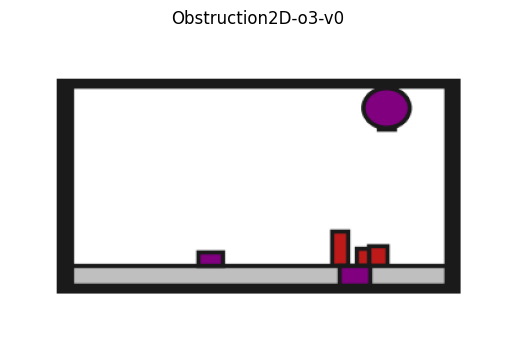

In [3]:
env = kinder.make("kinder/Obstruction2D-o3-v0", render_mode="rgb_array")
obs, info = env.reset(seed=42)

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Obstruction2D-o3-v0")
plt.show()

## Exploring the Observation and Action Spaces

KinDER environments follow the Gymnasium API. Observations and actions
are continuous-valued numpy arrays.

In [4]:
print("Observation shape:", env.observation_space.shape)
print("Action shape:     ", env.action_space.shape)
print()

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("Sample action:", np.round(action, 3))
print("Reward:       ", reward)
print("Terminated:   ", terminated)

Observation shape: (59,)
Action shape:      (5,)

Sample action: [-0.025 -0.009  0.065 -0.062  0.587]
Reward:        -1.0
Terminated:    False


## Rendering a Video

Let's collect frames from random actions and display them as an animated GIF.

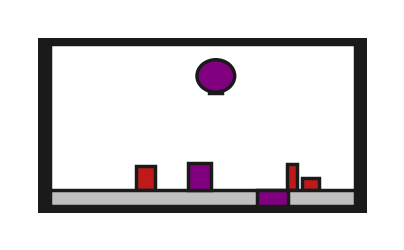

In [5]:
from io import BytesIO

from IPython.display import Image
from PIL import Image as PILImage

obs, info = env.reset(seed=0)
frames = [env.render()]
for _ in range(50):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())
    if terminated or truncated:
        break

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [6]:
env.close()